# Notebook 06 — Parameter Recovery with CustomDerivatives

One of the most powerful applications of UDEs is **recovering mechanistic parameters
from noisy data** when the structure of the dynamics is partially known. This notebook
demonstrates the full scientific workflow:

1. Generate data from a known system (SIR epidemic model)
2. Inject partial knowledge — recovery rate structure is known, transmission is not
3. Train `CustomDerivatives` to learn the unknown transmission while recovering `γ`
4. Inspect learned parameters and the neural transmission function
5. Forecast beyond the training window

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(3)
torch.manual_seed(3)

## 1 — Simulate the SIR Model

The SIR (Susceptible–Infectious–Recovered) model:
```
dS/dt = -β * S * I / N
dI/dt =  β * S * I / N  -  γ * I
dR/dt =  γ * I
```
True parameters: `β = 0.3`, `γ = 0.1`, `N = 1000`.

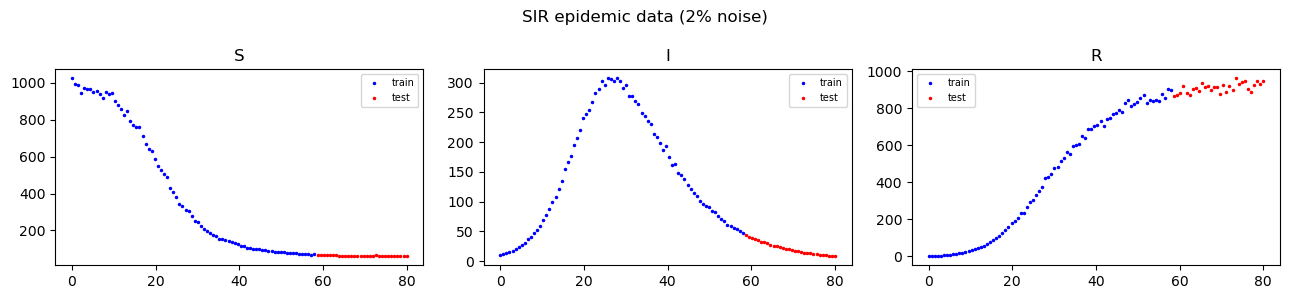

In [2]:
N     = 1000.0
BETA  = 0.3
GAMMA = 0.1
S0, I0, R0 = 990.0, 10.0, 0.0

def sir(t, u):
    S, I, R = u
    dS = -BETA * S * I / N
    dI =  BETA * S * I / N - GAMMA * I
    dR =  GAMMA * I
    return [dS, dI, dR]

t_span  = [0, 80]
t_all = np.linspace(0, 80, 110)

sol_full = solve_ivp(sir, [0, 80], [S0, I0, R0],
                     t_eval=t_all, method='RK45')

# Add 2% observation noise
noise = 0.02
n_all = len(sol_full.t)
cols  = ['S', 'I', 'R']
data_all = pd.DataFrame({'time': sol_full.t,
    'S': sol_full.y[0] * (1 + noise * np.random.randn(n_all)),
    'I': sol_full.y[1] * (1 + noise * np.random.randn(n_all)),
    'R': sol_full.y[2] * (1 + noise * np.random.randn(n_all)),
})
train_data = data_all.iloc[:80].reset_index(drop=True)
test_data  = data_all.iloc[80:].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col in zip(axes, cols):
    ax.plot(train_data['time'], train_data[col], 'b.', ms=3, label='train')
    ax.plot(test_data['time'],  test_data[col],  'r.', ms=3, label='test')
    ax.set_title(col); ax.legend(fontsize=7)
plt.suptitle('SIR epidemic data (2% noise)'); plt.tight_layout(); plt.show()

## 2 — Why NODE Cannot Recover Parameters

A plain `NODE` can fit the data, but it has no `get_params()` — the dynamics are
entirely encoded in opaque network weights with no interpretable structure.

In [3]:
node = ude.NODE(train_data, hidden_units=32)
node.train(loss='derivative_matching', epochs=150, verbose=False)
print('NODE is_trained:', node.is_trained)
print('NODE has get_params:', hasattr(node, 'get_params'))
fc_node = node.forecast(steps=len(test_data))
rmse_node = ude.rmse(test_data[cols].reset_index(drop=True),
                     fc_node[cols].reset_index(drop=True))['mean']
print(f'NODE test RMSE: {rmse_node:.2f}')

NODE is_trained: True
NODE has get_params: False
NODE test RMSE: 38.48


## 3 — CustomDerivatives: Inject Partial Knowledge

We know the **recovery structure** (`γ * I` removes individuals from I and adds them
to R). We do **not** know the transmission (`β * S * I / N`). The NN learns it.

In [4]:
def sir_known(u, p, t):
    """Known terms: recovery from I, gain in R. Transmission learned by NN."""
    S, I, R = u[0], u[1], u[2]
    gamma = p['gamma']
    return torch.stack([
        torch.zeros_like(S),   # S: transmission unknown — NN will fill this
        -gamma * I,            # I: recovery (known)
         gamma * I,            # R: gain from recovery (known)
    ])

model = ude.CustomDerivatives(
    train_data, sir_known,
    init_params={'gamma': 0.05},
    param_bounds={'gamma': (0.0, 1.0)},
    hidden_units=32,
)
print(model)

CustomDerivatives(states=3, columns=['S', 'I', 'R'], device='cpu', untrained)


## 4 — Multi-Stage Training

Stage 1: derivative matching (fast, no integration). Stage 2: simulation loss
(accurate, full ODE integration) with early stopping on training loss.

In [5]:
# Stage 1 — fast warm-up
model.train(loss='derivative_matching', epochs=200,
            learning_rate=1e-3, verbose=False)

# Stage 2 — accurate fine-tuning (requires torchdiffeq)
try:
    model.train(loss='simulation', epochs=200,
                learning_rate=3e-4, patience=50, verbose=False)
    print('Stage 2 (simulation) complete.')
except ImportError:
    print('torchdiffeq not installed — skipping simulation stage.')

print(f'Total epochs trained: {len(model.train_history_["train_loss"])}')

Stage 2 (simulation) complete.
Total epochs trained: 400


## 5 — Parameter Recovery

Recovered γ = 0.0828   (true γ = 0.1)
Relative error: 17.2%


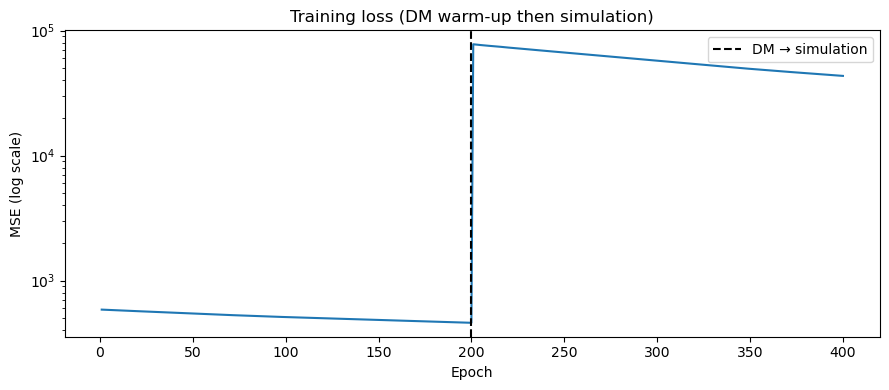

In [6]:
params = model.get_params()
print(f'Recovered γ = {params["gamma"]:.4f}   (true γ = {GAMMA})')
print(f'Relative error: {abs(params["gamma"] - GAMMA) / GAMMA * 100:.1f}%')

# Plot training history with stage boundary
history = model.train_history_
n_dm = 200  # epochs in stage 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(range(1, len(history['train_loss'])+1), history['train_loss'], lw=1.5)
ax.axvline(n_dm, color='k', ls='--', label='DM → simulation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.legend(); ax.set_title('Training loss (DM warm-up then simulation)')
plt.tight_layout(); plt.show()

## 6 — Inspect the Learned Transmission Term

Extract `get_right_hand_side()` and evaluate the NN contribution on a grid of
`(S, I)` values to see what transmission function was learned.

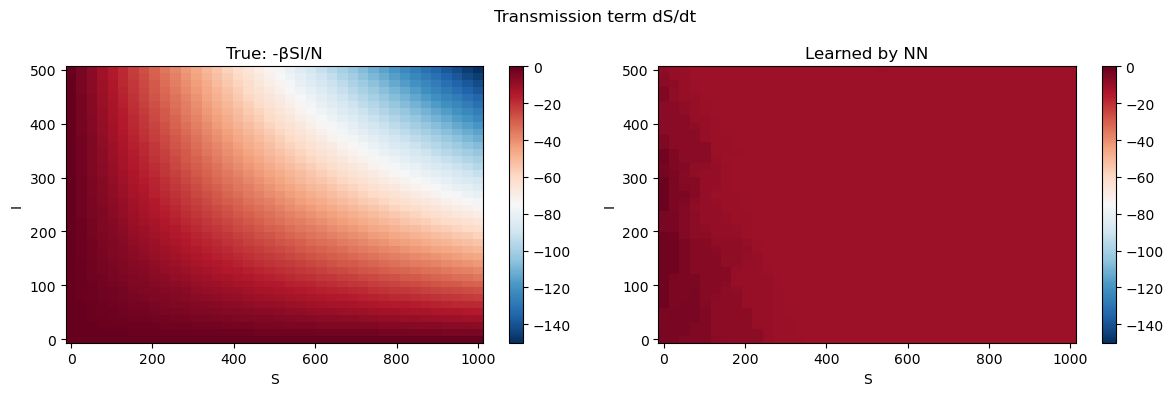

In [7]:
rhs = model.get_right_hand_side()  # f(u, t) -> du, numpy-compatible

# Evaluate NN contribution to dS/dt on an (S, I) grid
S_vals = np.linspace(0, 1000, 40)
I_vals = np.linspace(0, 500, 40)
SS, II = np.meshgrid(S_vals, I_vals)

# Theoretical: dS/dt transmission = -beta * S * I / N
true_trans = -BETA * SS * II / N

learned_trans = np.zeros_like(SS)
for i in range(40):
    for j in range(40):
        u = np.array([SS[i,j], II[i,j], N - SS[i,j] - II[i,j]])
        du = rhs(u, 0.0)
        learned_trans[i, j] = du[0]  # dS/dt component

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, title in zip(axes,
                        [true_trans, learned_trans],
                        ['True: -βSI/N', 'Learned by NN']):
    im = ax.pcolormesh(SS, II, Z, cmap='RdBu_r',
                       vmin=true_trans.min(), vmax=0)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('S'); ax.set_ylabel('I')
    ax.set_title(title)
plt.suptitle('Transmission term dS/dt'); plt.tight_layout(); plt.show()

## 7 — Forecast and Evaluation

R² per state:   {'S': -257.83476747952744, 'I': -0.7542486938232298, 'R': -3.92004760315716, 'mean': -87.50302125883594}
RMSE per state: {'S': 41.04220367256678, 'I': 14.142040066841572, 'R': 56.081605114855, 'mean': 40.94551750725646}


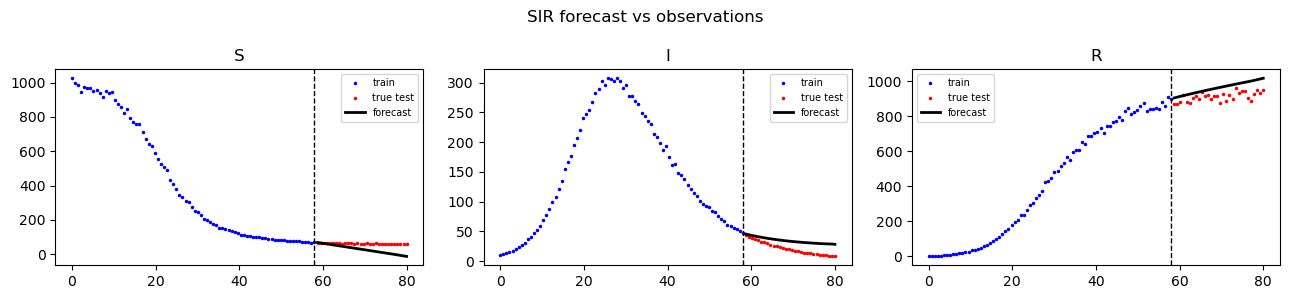

In [8]:
fc = model.forecast(steps=len(test_data))
min_len = min(len(fc), len(test_data))
obs_test = test_data[cols].iloc[:min_len].reset_index(drop=True)
pred_test = fc[cols].iloc[:min_len].reset_index(drop=True)

r2 = ude.r2_score(obs_test, pred_test)
rmse_cd = ude.rmse(obs_test, pred_test)
print('R² per state:  ', r2)
print('RMSE per state:', rmse_cd)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col in zip(axes, cols):
    ax.plot(train_data['time'], train_data[col], 'b.', ms=3, label='train')
    ax.plot(test_data['time'],  test_data[col],  'r.', ms=3, label='true test')
    ax.plot(fc['time'], fc[col], 'k-', lw=2, label='forecast')
    ax.axvline(train_data['time'].iloc[-1], color='k', ls='--', lw=1)
    ax.set_title(col); ax.legend(fontsize=7)
plt.suptitle('SIR forecast vs observations'); plt.tight_layout(); plt.show()

## 8 — Effect of `param_bounds`

In [9]:
model_no_bounds = ude.CustomDerivatives(
    train_data, sir_known,
    init_params={'gamma': 0.05},   # no bounds
    hidden_units=32,
)
model_no_bounds.train(loss='derivative_matching', epochs=200, verbose=False)
gamma_nb = model_no_bounds.get_params()['gamma']
gamma_b  = model.get_params()['gamma']

print(f'True γ:         {GAMMA}')
print(f'Recovered (bounded):   {gamma_b:.4f}')
print(f'Recovered (unbounded): {gamma_nb:.4f}  '
      f'({"NEGATIVE — physically invalid!" if gamma_nb < 0 else "OK"})')

True γ:         0.1
Recovered (bounded):   0.0828
Recovered (unbounded): 0.0496  (OK)


## Key Takeaways

- `CustomDerivatives` separates **known mechanistic structure** from **unknown residuals**.
- `get_params()` returns learned parameter values as plain floats — directly interpretable.
- `param_bounds` prevents the optimizer from pushing parameters into physically impossible
  ranges (e.g. negative rates).
- `get_right_hand_side()` lets you inspect the learned NN term as a function over state space.
- Multi-stage training (DM warm-up → simulation fine-tune) is the recommended workflow
  for parameter recovery tasks.